#**Toma de decisiones organizacionales**
###**Realizado por** Juan Esteban Gamba, Sofia Forero Estupiñan y Jose Gabriel Vega Forero

El dataset Emergency - 911 Calls contiene 663.523 registros de llamadas de emergencias en el condado de Montgomery, Pennsylvania, entre el 2015 y el 2020.

Los datos se obtuvieron de Kaggle en el enlace: https://www.kaggle.com/datasets/mchirico/montcoalert/data



In [13]:
!pip install gdown openpyxl
!pip install plotly

In [14]:
import gdown
import pandas as pd
from google.colab import files

file_id = '1IM0RMXPC9yQvp7jLXY3Toqix0A7oHzPT'
output_name = '911.csv'
gdown.download(id=file_id, output=output_name)
df = pd.read_csv(output_name, header=None)
#
print("📊 Primeros 10 registros del archivo (con columnas asignadas):")
print(df.head(10))

#output_excel = 'BASE.xlsx'
#df.to_excel(output_excel, index=False)
#files.download(output_excel)

Downloading...
From (original): https://drive.google.com/uc?id=1IM0RMXPC9yQvp7jLXY3Toqix0A7oHzPT
From (redirected): https://drive.google.com/uc?id=1IM0RMXPC9yQvp7jLXY3Toqix0A7oHzPT&confirm=t&uuid=55ea700b-0b50-4ebf-9bfe-73eff72ee515
To: /content/911.csv
100%|██████████| 123M/123M [00:01<00:00, 94.1MB/s]


📊 Primeros 10 registros del archivo (con columnas asignadas):
            0            1                                                  2  \
0         lat          lng                                               desc   
1  40.2978759  -75.5812935  REINDEER CT & DEAD END;  NEW HANOVER; Station ...   
2  40.2580614  -75.2646799  BRIAR PATH & WHITEMARSH LN;  HATFIELD TOWNSHIP...   
3  40.1211818  -75.3519752  HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...   
4  40.1161530  -75.3435130  AIRY ST & SWEDE ST;  NORRISTOWN; Station 308A;...   
5  40.2514920  -75.6033497  CHERRYWOOD CT & DEAD END;  LOWER POTTSGROVE; S...   
6  40.2534732  -75.2832450  CANNON AVE & W 9TH ST;  LANSDALE; Station 345;...   
7  40.1821111  -75.1277951  LAUREL AVE & OAKDALE AVE;  HORSHAM; Station 35...   
8  40.2172859  -75.4051820  COLLEGEVILLE RD & LYWISKI RD;  SKIPPACK; Stati...   
9  40.2890267  -75.3995896  MAIN ST & OLD SUMNEYTOWN PIKE;  LOWER SALFORD;...   

       3                           4          

/tmp/ipykernel_2066/2825551154.py:8: DtypeWarning:

Columns (0,1,3,8) have mixed types. Specify dtype option on import or set low_memory=False.



#Dimension de dataset

In [15]:
df.shape

(663523, 9)

Tipo de dato

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663523 entries, 0 to 663522
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   0       663523 non-null  object
 1   1       663523 non-null  object
 2   2       663523 non-null  object
 3   3       583324 non-null  object
 4   4       663523 non-null  object
 5   5       663523 non-null  object
 6   6       663230 non-null  object
 7   7       663523 non-null  object
 8   8       663523 non-null  object
dtypes: object(9)
memory usage: 45.6+ MB


1. Preparación de datos

Se realizo una conversión de variables y limpieza de las data

In [17]:
column_names = df.iloc[0].values
df.columns = column_names
# Convertir a float
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lng'] = pd.to_numeric(df['lng'], errors='coerce')
# Convertir a datetime
df['timeStamp'] = pd.to_datetime(df['timeStamp'], errors='coerce')
# Eliminar
df = df.drop(columns=['e'])
df.info()

/tmp/ipykernel_2066/1582190210.py:7: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663523 entries, 0 to 663522
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   lat        663522 non-null  float64       
 1   lng        663522 non-null  float64       
 2   desc       663523 non-null  object        
 3   zip        583324 non-null  object        
 4   title      663523 non-null  object        
 5   timeStamp  663522 non-null  datetime64[ns]
 6   twp        663230 non-null  object        
 7   addr       663523 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 40.5+ MB


2. Evaluación de valores nulos

Se encontró en la variable de código postal (zip) un 12% de valores faltantes, lo cual puede ser un error en el registro de la base de datos o puede que la zona no tenga código postal asignado, sin embargo, esta variable no representa una variable critica para el análisis del presente trabajo


--- VALORES NULOS POR COLUMNA ---
           Nulos  Porcentaje (%)
Columnas                        
lat            1            0.00
lng            1            0.00
desc           0            0.00
zip        80199           12.09
title          0            0.00
timeStamp      1            0.00
twp          293            0.04
addr           0            0.00


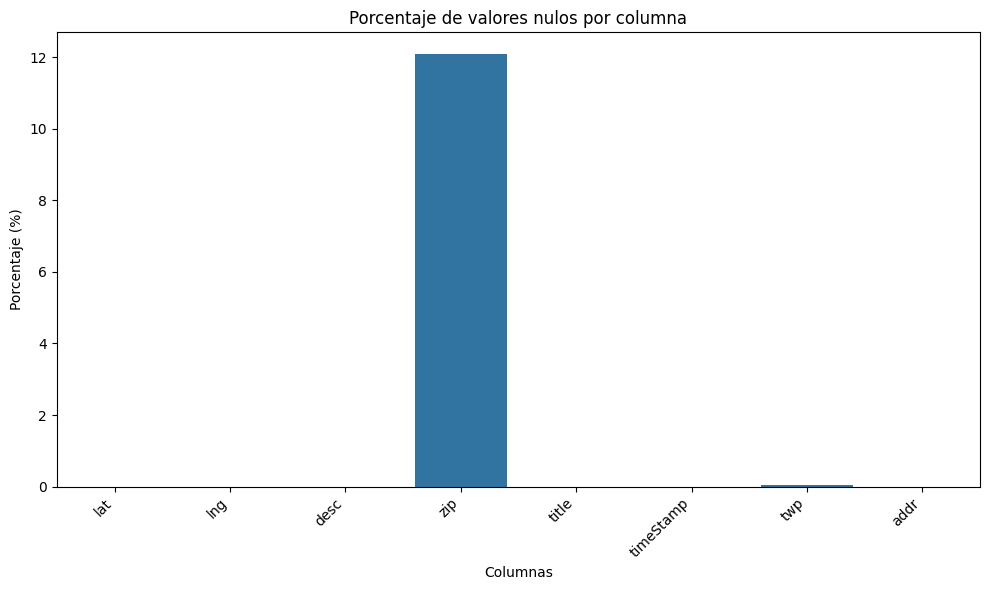

In [18]:
# Contar null
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
null_table = pd.DataFrame({'Nulos': null_counts, 'Porcentaje (%)': null_percent.round(2)})
null_table.index.name = 'Columnas'
print("\n--- VALORES NULOS POR COLUMNA ---")
print(null_table)

# Grafica Nulos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=null_table.index, y=null_table['Porcentaje (%)'])
plt.xticks(rotation=45, ha='right')
plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje (%)')
plt.tight_layout()
plt.show()

3. Análisis de variables categóricas principales

Grafico 3.1:
Con el fin de mitigar la gran mayoría de las incidencias, se debe priorizar la atención en las siguientes categorías clave, las cuales representan aproximadamente el 80% del volumen total de casos según el análisis de Pareto:

1. Traffic: VEHICLE ACCIDENT
2. Traffic: DISABLED VEHICLE
3. Fire: FIRE ALARM
4. EMS: FALL VICTIM
5. EMS: RESPIRATORY EMERGENCY
6. EMS: CARDIAC EMERGENCY


Grafico 3.2:
Este diagrama de Pareto analiza la distribución de llamadas por municipio, integrando la frecuencia absoluta de eventos con su porcentaje acumulado. El análisis evidencia que los municipios comprendidos entre Lower Merion y Upper Moreland concentran aproximadamente el 80% del total de las llamadas, permitiendo focalizar la atención y optimizar la asignación de recursos operativos en estas zonas prioritarias.


--- TOP 10 TIPOS DE INCIDENTES ---
                              count  cum_sum  cum_percentage
title                                                       
Traffic: VEHICLE ACCIDENT -  148372   148372       35.111982
Traffic: DISABLED VEHICLE -   47909   196281       46.449566
Fire: FIRE ALARM              38336   234617       55.521715
EMS: FALL VICTIM              34676   269293       63.727731
EMS: RESPIRATORY EMERGENCY    34248   303541       71.832462
EMS: CARDIAC EMERGENCY        32332   335873       79.483775
EMS: VEHICLE ACCIDENT         25513   361386       85.521384
Traffic: ROAD OBSTRUCTION -   23235   384621       91.019907
EMS: SUBJECT IN PAIN          19646   404267       95.669099
EMS: HEAD INJURY              18301   422568      100.000000


/tmp/ipykernel_2066/4038461459.py:28: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



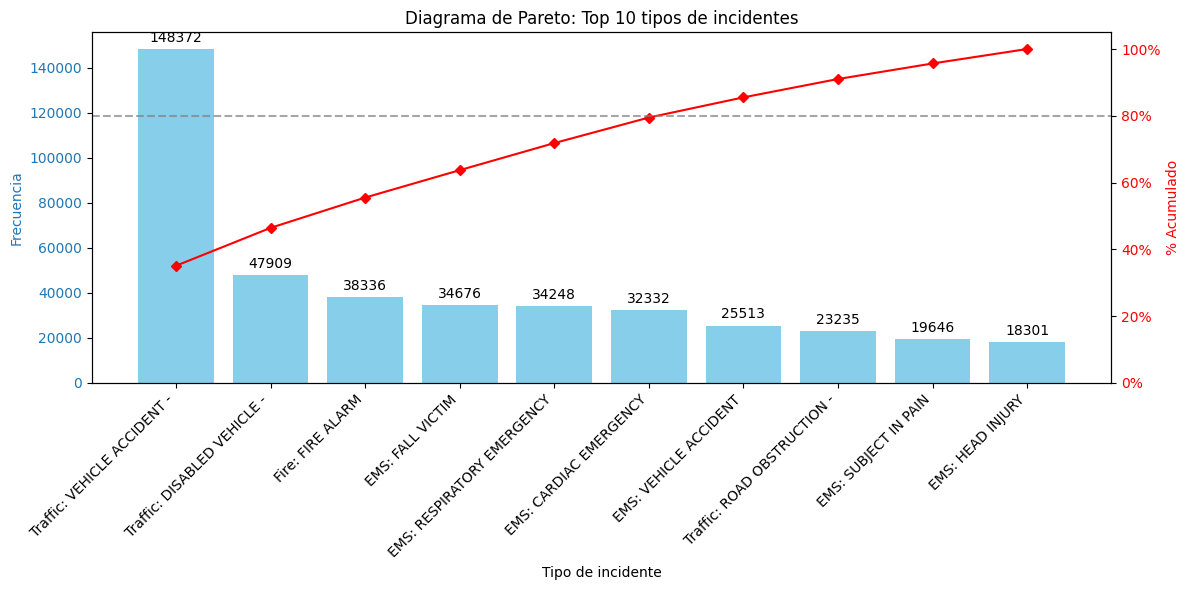


--- 3.1 TOP 10 MUNICIPIOS ---
                  count  cum_sum  cum_percentage
twp                                             
LOWER MERION      55490    55490       17.817980
ABINGTON          39947    95437       30.645063
NORRISTOWN        37633   133070       42.729115
UPPER MERION      36010   169080       54.292017
CHELTENHAM        30574   199654       64.109406
POTTSTOWN         27387   227041       72.903441
UPPER MORELAND    22932   249973       80.266965
LOWER PROVIDENCE  22476   272449       87.484065
PLYMOUTH          20116   292565       93.943364
UPPER DUBLIN      18862   311427      100.000000


/tmp/ipykernel_2066/4038461459.py:58: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



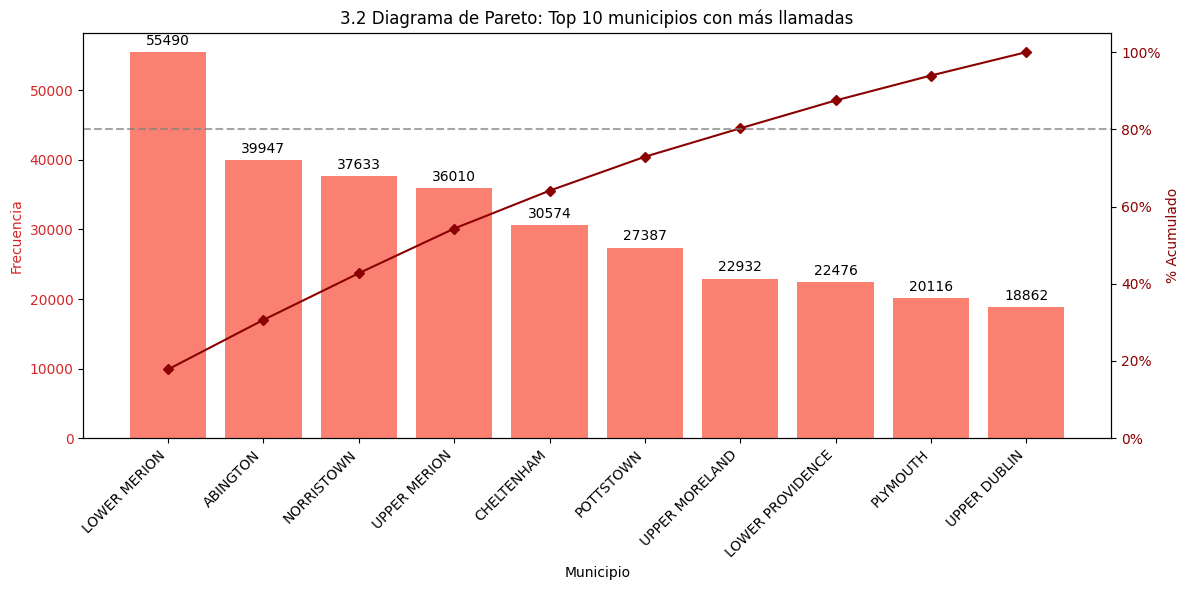

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- 1. PARETO DE TIPOS DE INCIDENTES ---
top_titles = df['title'].value_counts().head(10).to_frame(name='count')
top_titles['cum_sum'] = top_titles['count'].cumsum()
top_titles['cum_percentage'] = top_titles['cum_sum'] / top_titles['count'].sum() * 100

print("\n--- TOP 10 TIPOS DE INCIDENTES ---")
print(top_titles)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(top_titles.index, top_titles['count'], color='skyblue')
ax1.set_xlabel('Tipo de incidente')
ax1.set_ylabel('Frecuencia', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.bar_label(bars, padding=3)

ax2 = ax1.twinx()
ax2.plot(top_titles.index, top_titles['cum_percentage'], color='red', marker='D', ms=5)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('% Acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 105)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)

ax1.set_xticklabels(top_titles.index, rotation=45, ha='right')
plt.title('Diagrama de Pareto: Top 10 tipos de incidentes')
plt.tight_layout()
plt.show()


# --- 2. PARETO DE MUNICIPIOS ---
top_twp = df['twp'].value_counts().head(10).to_frame(name='count')
top_twp['cum_sum'] = top_twp['count'].cumsum()
top_twp['cum_percentage'] = top_twp['cum_sum'] / top_twp['count'].sum() * 100

print("\n--- 3.1 TOP 10 MUNICIPIOS ---")
print(top_twp)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(top_twp.index, top_twp['count'], color='salmon')
ax1.set_xlabel('Municipio')
ax1.set_ylabel('Frecuencia', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.bar_label(bars, padding=3)

ax2 = ax1.twinx()
ax2.plot(top_twp.index, top_twp['cum_percentage'], color='darkred', marker='D', ms=5)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel('% Acumulado', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.set_ylim(0, 105)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)

ax1.set_xticklabels(top_twp.index, rotation=45, ha='right')
plt.title('3.2 Diagrama de Pareto: Top 10 municipios con más llamadas')
plt.tight_layout()
plt.show()

3.3 Los accidentes vehiculares representan la mayor causa de accidentalidad en la sección de tráfico con 148.372 registros, cabe recalcar que en el top de 3 se encuentra una gran cantidad de llamadas de vehículos averiados, por ende, se podría considerar habilitar una línea de apoyo para no congestionar el sistema de emergencias

3.4 Las caídas (34.676), emergencias respiratorias (34.248) y cardíacas (32.332) son los servicios médicos más solicitados, valdría la pena identificar los rangos de edad de las personas de la población, ya que parecen patologías relacionadas con personas de la tercera edad

3.5 Las alarmas de incendio presentan una demanda de 38.336 registros, siendo el servicio más frecuente de la categoría, por ende, una fracción de esos informes podrían ser falsos positivos que reportan en el sistema, por lo que es importante generar campañas de concientización


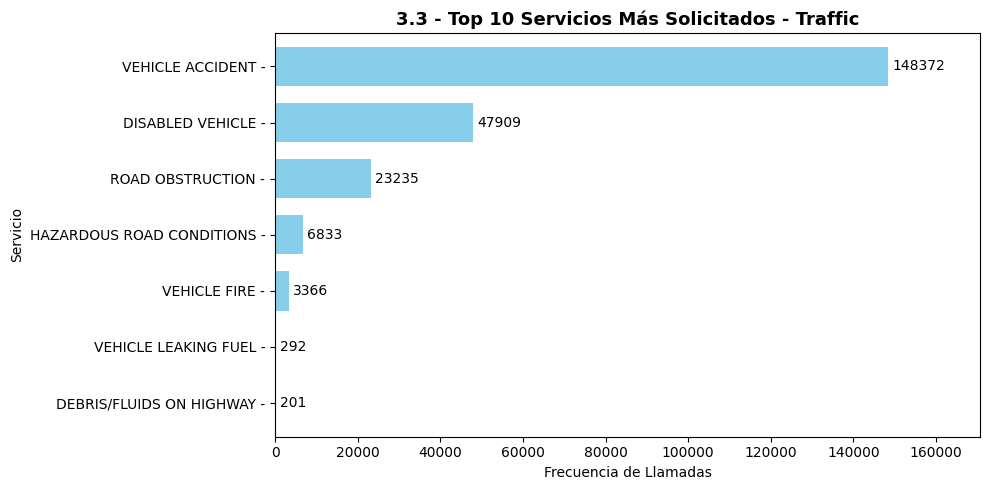

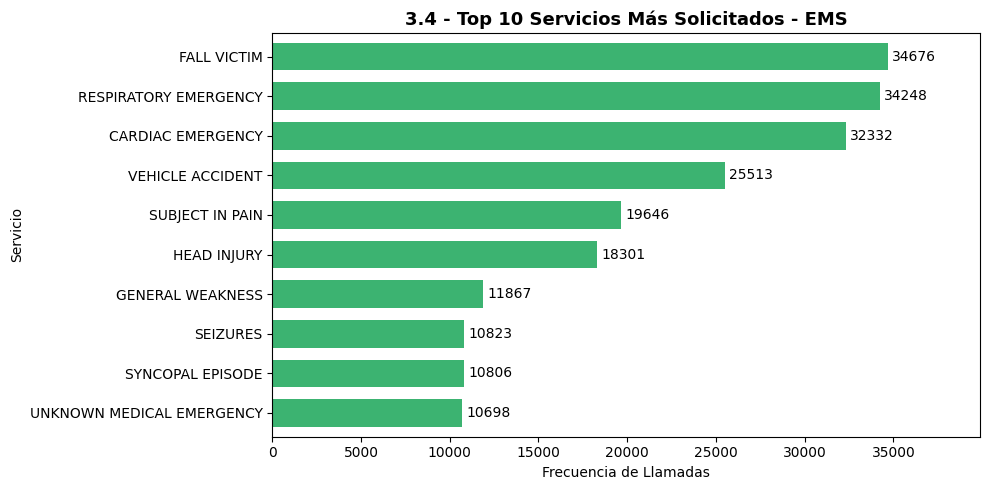

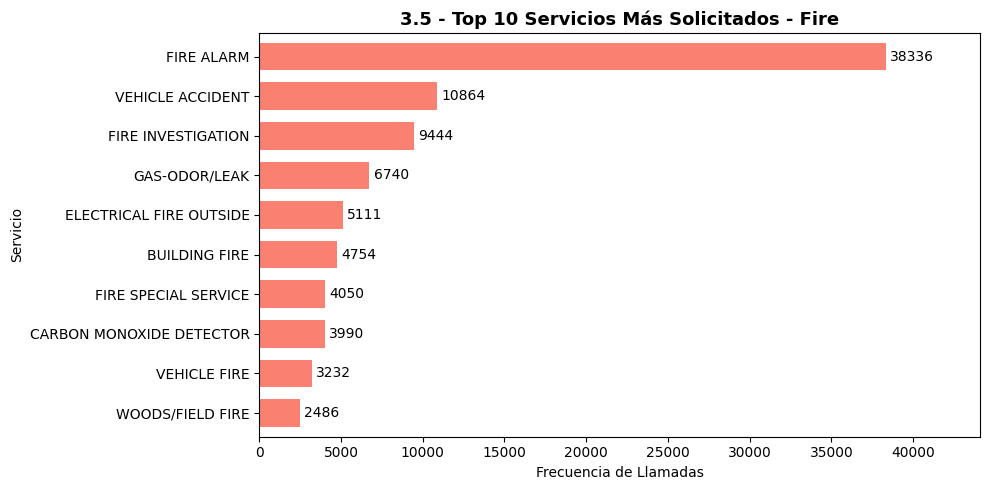

In [20]:
import matplotlib.pyplot as plt

df["Category"] = df["title"].apply(
    lambda x: str(x).split(":")[0] if ":" in str(x) else str(x)
)
df["Service"] = df["title"].apply(
    lambda x: str(x).split(":")[1].strip() if ":" in str(x) else str(x)
)

categories = ["Traffic", "EMS", "Fire"]
colors = {"Traffic": "skyblue", "EMS": "mediumseagreen", "Fire": "salmon"}

for i, cat in enumerate(categories, start=1):
    top_services = df[df["Category"] == cat]["Service"].value_counts().head(10)

    plt.figure(figsize=(10, 5))

    ax = top_services.sort_values().plot(
        kind="barh", color=colors[cat], width=0.7
    )
    ax.bar_label(ax.containers[0], padding=3)

    plt.margins(x=0.15)
    plt.title(
        f"3.{i+2} - Top 10 Servicios Más Solicitados - {cat}",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Frecuencia de Llamadas")
    plt.ylabel("Servicio")
    plt.tight_layout()
    plt.show()

4. Análisis temporal

4.1 La serie de tiempo tiene tendencia de demanda ascendente en el numero de llamada del 2015 al 2020, cual podría deberse a un aumento en la población o una mayor conciencia sobre el uso del servicio de emergencias

4.2 La actividad presenta notables picos entra las 10:00 y las 12:00, además también se presenta un periodo de 16:00 a las 18:00, este parámetro se puede presentar debido que son los momentos con mayor movilidad

4.3 Los días entre semana presentan un volumen de llamadas similar, excepto el día viernes donde se presenta la mayor demanda, por otro lado, el día domingo es el da con menor demanda


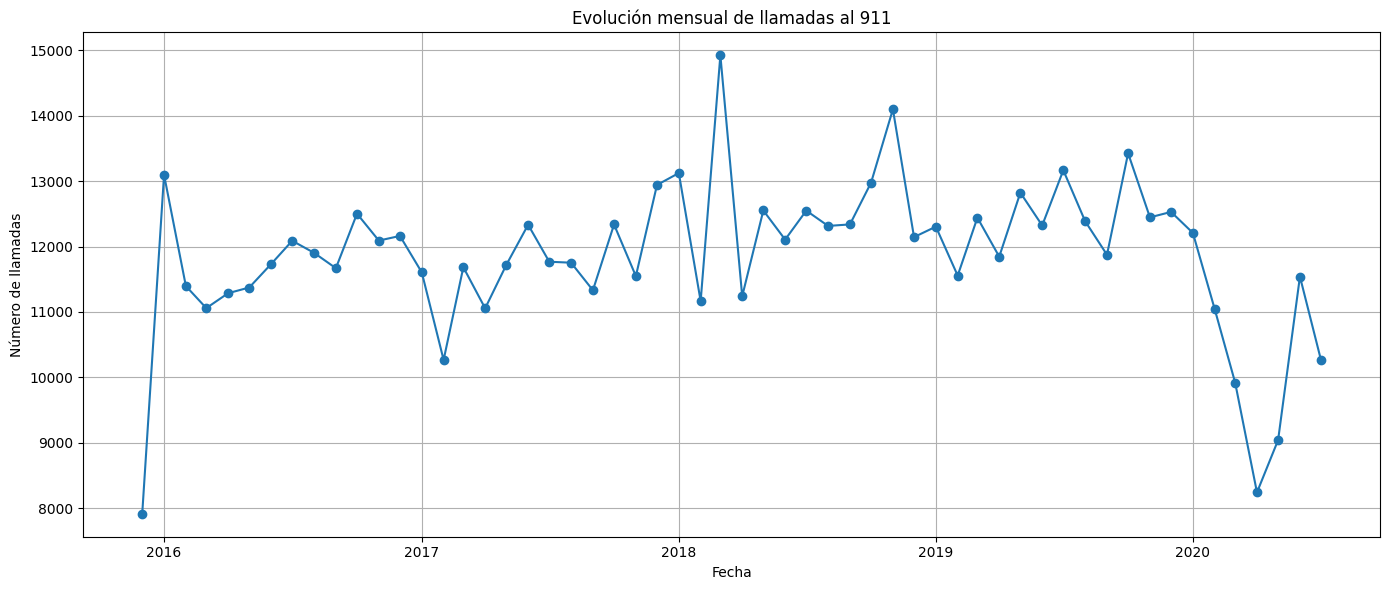

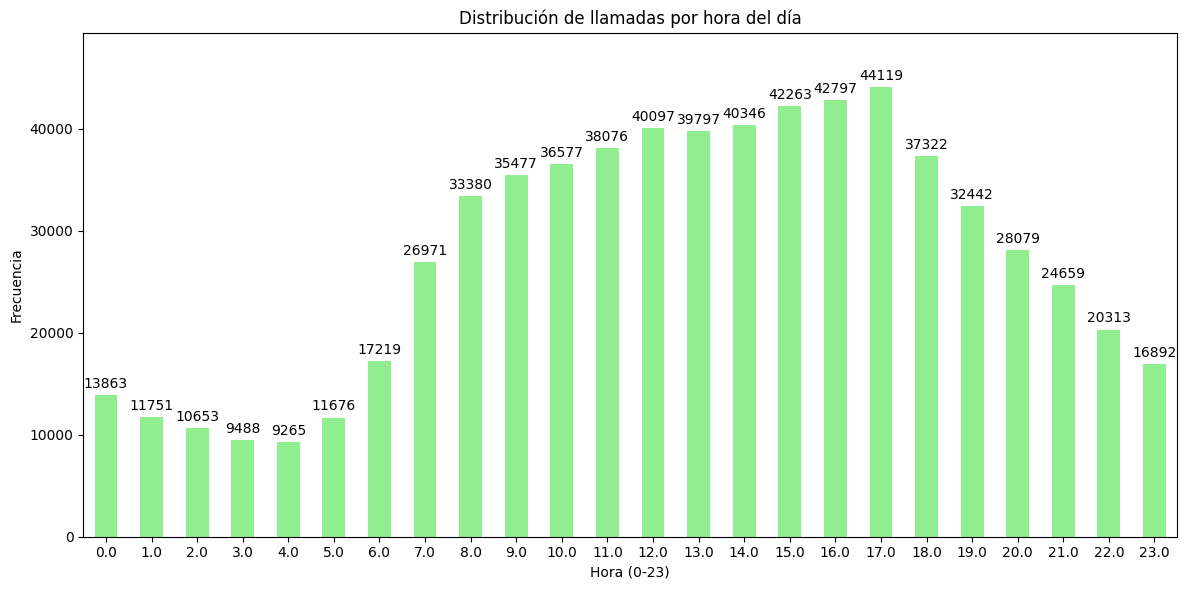

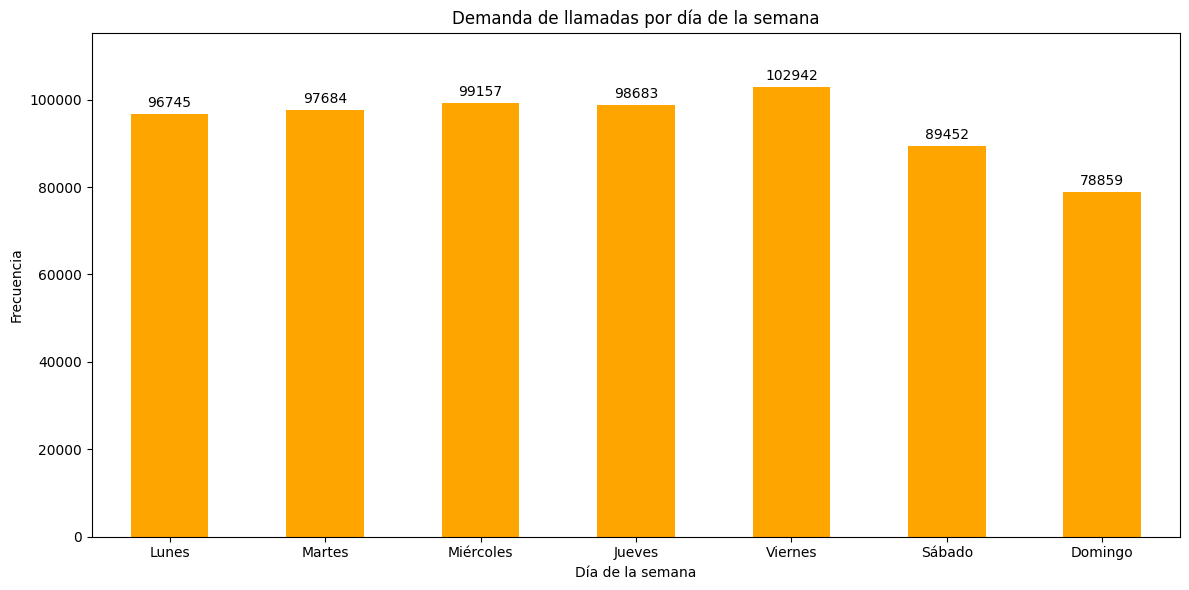

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

df['year'] = df['timeStamp'].dt.year
df['month'] = df['timeStamp'].dt.month
df['day'] = df['timeStamp'].dt.day
df['hour'] = df['timeStamp'].dt.hour

incidentes_por_mes = df.groupby(['year', 'month']).size().reset_index(name='count')
incidentes_por_mes['fecha'] = pd.to_datetime(incidentes_por_mes[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 6))
plt.plot(incidentes_por_mes['fecha'], incidentes_por_mes['count'], marker='o', linestyle='-')
plt.title('Evolución mensual de llamadas al 911')
plt.xlabel('Fecha')
plt.ylabel('Número de llamadas')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
hour_counts = df['hour'].value_counts().sort_index()
ax1 = hour_counts.plot(kind='bar', color='lightgreen')
ax1.bar_label(ax1.containers[0], padding=3)
plt.margins(y=0.12)
plt.title('Distribución de llamadas por hora del día')
plt.xlabel('Hora (0-23)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
dias_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

df['day_of_week'] = df['timeStamp'].dt.dayofweek.map(dias_map)
dow_counts = df['day_of_week'].value_counts().reindex(dias_semana)

plt.figure(figsize=(12, 6))
ax2 = dow_counts.plot(kind='bar', color='orange')
ax2.bar_label(ax2.containers[0], padding=3)
plt.margins(y=0.12)
plt.title('Demanda de llamadas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

5. Mapa de densidad de incidentes

5.1 El mapa de densidad muestra una mayor concentración de incidentes en el área central y el sur del condado, este mapa es una herramienta visual fundamental para la planificación territorial de los servicios de emergencia

5.2 El mapa de dispersión indica una muestra de 1000 puntos, donde se visualiza la distribución espacial de los diferentes tipos de incidentes. Cabe recalcar que los incendios son más frecuentes en zonas urbanas.

In [22]:
import plotly.express as px
df_map = df.dropna(subset=["lat", "lng"]).copy()
df_map = df_map.sample(n=1000, random_state=42)

# 2. Mapa de densidad
fig = px.density_mapbox(
    df_map,
    lat="lat",
    lon="lng",
    radius=10,
    center=dict(lat=40.2, lon=-75.3),
    zoom=9,
    mapbox_style="open-street-map",
    title="5.1 Densidad de incidentes 911",
)
fig.show()

# 3. Mapa de dispersión
sample = df_map.sample(n=1000, random_state=42)

fig_scatter = px.scatter_mapbox(
    sample,
    lat="lat",
    lon="lng",
    color="title",
    hover_data=["twp", "timeStamp"],
    zoom=9,
    center=dict(lat=40.2, lon=-75.3),
    mapbox_style="open-street-map",
    title="5.2 Muestra de incidentes (1000 puntos)",
)
fig_scatter.show()

6. Análisis de correlación entre variables numéricas

La mayoría de los coeficientes son cercanos a cero, lo que indica que no existe una dependencia lineal significativa entre la ubicación geográfica y las dimensiones temporales

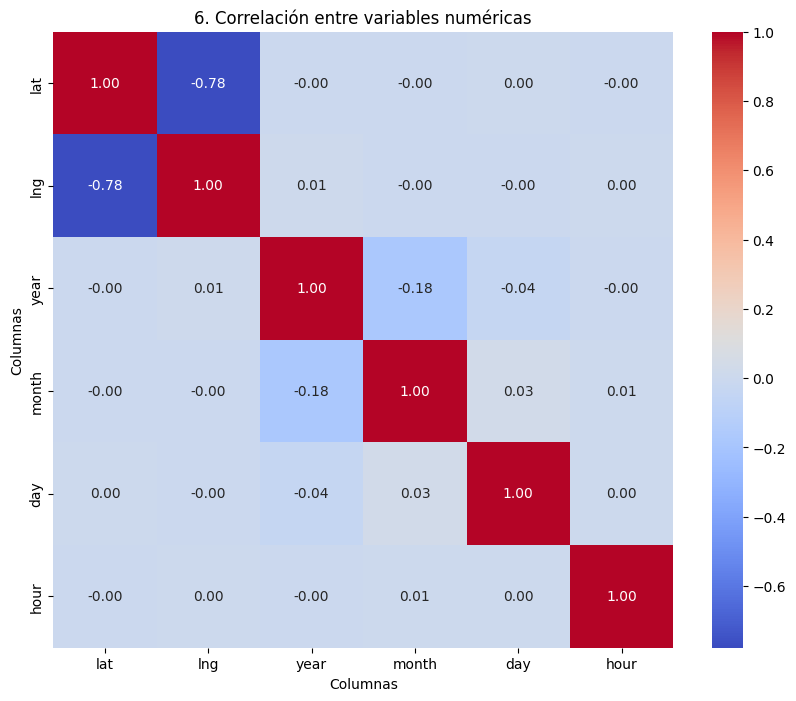

In [23]:
num_cols = df[['lat', 'lng', 'year', 'month', 'day', 'hour']].select_dtypes(include='number')
plt.figure(figsize=(10,8))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('6. Correlación entre variables numéricas')
plt.show()